In [1]:
from astroquery_updated.esa.euclid import Euclid
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np
from astropy.table import Table, vstack
import healsparse as hsp
import healpy as hp
from hpgeom import hpgeom
import skyproj
import ugali.utils.healpix as healpix
import matplotlib.pyplot as plt

my_path =  '/sdf/data/rubin/user/kexcel/'
my_plotspath = my_path + 'plots/'

Euclid.get_status_messages()  # check archive isn't degraded

In [2]:
tables = Euclid.load_tables(only_names=True, include_shared_tables=True)
map_names = [t.name for t in tables if 'q1.vmpz' in t.name.lower()]
#q1.vmpz_healpix_bitmask ?
#q1.vmpz_healpix_coverage
#q1.vmpz_healpix_depthmap
#q1.vmpz_healpix_footprint_mask
#q1.vmpz_healpix_infomap
#q1.mer_segmentation_map

INFO: Retrieving tables... [astroquery.utils.tap.core]


INFO: Parsing tables... [astroquery.utils.tap.core]


INFO: Done. [astroquery.utils.tap.core]


In [3]:
tile = [t.name for t in tables if 'q1' in t.name.lower()]
tile

['q1.basic_download_data',
 'q1.raw_detector',
 'q1.raw_frame',
 'q1.raw_quadrant',
 'q1.aux_calibrated',
 'q1.aux_mosaic',
 'q1.aux_stacked',
 'q1.calibrated_detectors',
 'q1.calibrated_frame',
 'q1.combined_spectra',
 'q1.combined_spectra_product',
 'q1.data_release',
 'q1.frame_catalog',
 'q1.mer_final_catalogue',
 'q1.mer_segmentation_map',
 'q1.mosaic_product',
 'q1.observation_mosaic',
 'q1.observation_stack',
 'q1.phz_catalogue',
 'q1.phz_catalogue_l3',
 'q1.provenance',
 'q1.sir_frame_detectors',
 'q1.sir_science_frame',
 'q1.spe_catalogue',
 'q1.spectra_source',
 'q1.vmpz_healpix_bitmask',
 'q1.vmpz_healpix_coverage',
 'q1.vmpz_healpix_depthmap',
 'q1.vmpz_healpix_footprint_mask',
 'q1.vmpz_healpix_infomap']

In [70]:
ra = 58.8
dec = -51.5
radius = 0.5
## below loads in file paths to download similar to the maps
#catalog_name = 'q1.mer_final_catalogue'
#mer_query = f''' SELECT * FROM {catalog_name}
#            '''
#mer_results = Euclid.launch_job_async(mer_query).get_results()

query = f'''
        SELECT right_ascension, declination, point_like_prob, point_like_flag,
        ellipticity, mumax_minus_mag, flux_vis_psf, fluxerr_vis_psf, spurious_flag,
        det_quality_flag, fwhm, segmentation_map_id
        FROM mer_catalogue WHERE DISTANCE({ra}, {dec}, right_ascension, declination) < {radius}
        '''
#mer_results = Euclid.cone_search(coordinate=coord, radius=1 * u.degree).get_results()#, columns = ['tileId'])
#or WHERE right_ascension BETWEEN ra1 AND ra2 and declination BETWEEN dec1 AND dec2

mer_results = Euclid.launch_job_async(query, verbose=False).get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [48]:
mer_results

In [49]:
#for map_name in map_names:
map_name = 'q1.vmpz_healpix_coverage'
map_query = f"SELECT * FROM {map_name}"
map_results = Euclid.launch_job_async(map_query).get_results()
map_results.sort('file_path')

INFO: Query finished. [astroquery.utils.tap.core]


In [50]:
#query = f"SELECT tile_index, ra, dec FROM q1.mosaic_product"
#query = "SELECT * FROM q1.observation_mosaic"
#results = Euclid.launch_job_async(query).get_results()
#results.sort('tile_index') #[['tile_index','ra','dec']]
#results

In [71]:
n = 1
start = 8 #start at 0, add 8 to get to the next tile
for i in range(start, start+8):
    tileid = map_results['tile_index_list'][i][0]
    print(tileid)
    output_path = f"euclid_data/{map_name[map_name.rfind('_')+1:]}_{tileid}_{n}.fits"
    print(output_path)
    path = Euclid.get_product(file_name=map_results['file_name_list'][i], product_id = map_results['product_id'][i], 
                              output_file=output_path, verbose=False)
    n += 1

102018212
euclid_data/coverage_102018212_1.fits
102018212
euclid_data/coverage_102018212_2.fits
102018212
euclid_data/coverage_102018212_3.fits
102018212
euclid_data/coverage_102018212_4.fits
102018212
euclid_data/coverage_102018212_5.fits
102018212
euclid_data/coverage_102018212_6.fits
102018212
euclid_data/coverage_102018212_7.fits
102018212
euclid_data/coverage_102018212_8.fits


Ok so it does seem that these are 8 maps covering the same area. Based on the website I had found before, I think they're just different observation times. I don't understand why there are some maps with just 0 then....

In [52]:
#results[['file_path','tile_index_list']][8:16]
for row in range(len(map_results['tile_index_list'])):
    if len(map_results['tile_index_list'][row]) < 1:
        print(map_results[['file_path','tile_index_list']][row])

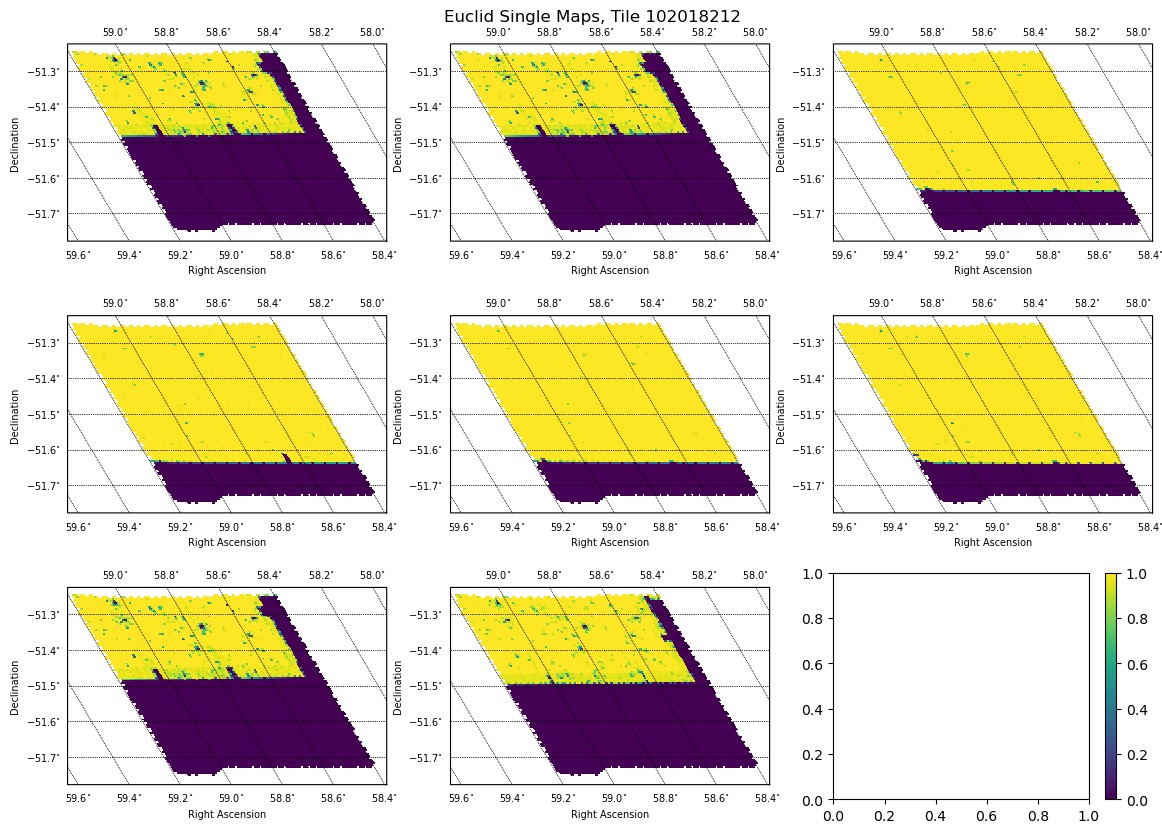

In [72]:
fig, ax = plt.subplots(3,3,figsize=(14, 10))
map_list = []
for n in range(1,9):
    # ! need to figure out if this nside_coverage is telling hsp which coverage to read in 
        # or if it makes an assumption about the properties of this map
    single_map = hsp.HealSparseMap.read(f'euclid_data/{map_name[map_name.rfind('_')+1:]}_{tileid}_{n}.fits', nside_coverage=32)
    map_list.append(single_map)
    sp = skyproj.MollweideSkyproj(ax=ax.flatten()[n-1])
    sp.draw_hspmap(single_map)
    sp.ax.set_xlabel("Right Ascension", fontsize = 7)
    sp.ax.set_ylabel("Declination", fontsize = 7)
    sp.ax.tick_params(axis = "x", labelsize=7)
    sp.ax.tick_params(axis = "y", labelsize=7)
plt.suptitle(f'Euclid Single Maps, Tile {tileid}', y=.9)
plt.colorbar(ax = ax[2][2])
#plt.tight_layout()
#plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_single_euclidcoveragemap.png')
plt.show()

In [73]:
mask = (mer_results['spurious_flag']==0)
mask &= (mer_results['segmentation_map_id'] // 10**6 == tileid)
mer_results_clean = mer_results[mask]

combined_map = hsp.operations.sum_union(map_list)

In [55]:
fracdet = combined_map.fracdet_map(512)
#fracdet.

In [56]:
#fracdet_zero = np.tile(0,len(fracdet))
#cut = (fracdet != hp.UNSEEN)
#fracdet_zero[cut] = fracdet[cut]

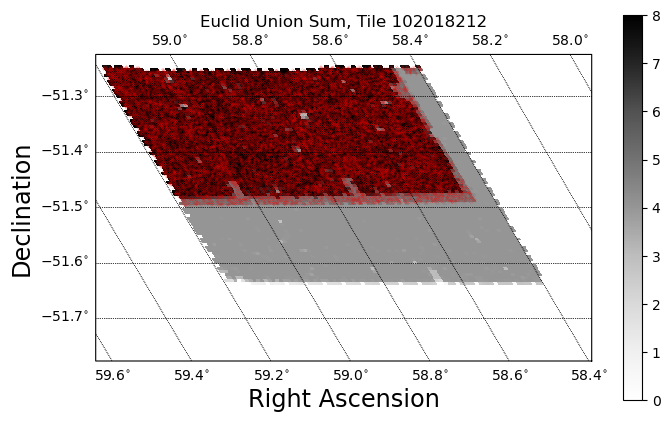

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(combined_map,cmap='Greys')
sp.ax.scatter(mer_results_clean['right_ascension'],mer_results_clean['declination'],s=.005,c='r')
plt.title(f'Euclid Union Sum, Tile {tileid}', pad = 20)
plt.colorbar()
#plt.tight_layout()
#plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_sumunion_euclidcoveragemap.png')
plt.show()

In [ ]:
start = 8*5
n = 1
for i in range(start, start+8):
    tileid = results['tile_index_list'][i][0]
    print(tileid)
    output_path = f"euclid_data/coverage_map_{tileid}_{n}.fits"
    print(output_path)
    path = Euclid.get_product(file_name=results['file_name_list'][i], product_id = results['product_id'][i], 
                              output_file=output_path, verbose=False)
    n += 1

fig, ax = plt.subplots(3,3,figsize=(14, 10))
covmap_list = []
for n in range(1,9):
    # ! need to figure out if this nside_coverage is telling hsp which coverage to read in 
        # or if it makes an assumption about the properties of this map
    mapa = hsp.HealSparseMap.read(f'euclid_data/coverage_map_{tileid}_{n}.fits', nside_coverage=32)
    covmap_list.append(mapa)
    sp = skyproj.MollweideSkyproj(ax=ax.flatten()[n-1])
    sp.draw_hspmap(mapa)
    sp.ax.set_xlabel("Right Ascension", fontsize = 7)
    sp.ax.set_ylabel("Declination", fontsize = 7)
    sp.ax.tick_params(axis = "x", labelsize=7)
    sp.ax.tick_params(axis = "y", labelsize=7)
plt.suptitle(f'Euclid Coverage Single Maps, Tile {tileid}', y=.9)
plt.colorbar(ax = ax[2][2])
#plt.tight_layout()
plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_single_euclidcoveragemap.png')
plt.show()

covmap = hsp.operations.sum_union(covmap_list)
fig, ax = plt.subplots(figsize=(8, 5))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(covmap)
plt.title(f'Euclid Coverage Union Sum, Tile {tileid}', pad = 20)
plt.colorbar()
#plt.tight_layout()
plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_sumunion_euclidcoveragemap.png')
plt.show()

In [ ]:
'''
valid = Euclid.get_valid_le3_configuration_values()
for row in range(len(valid)):
    if 'VMPZ' in valid['product_type'][row]:
    #if valid['product_type'][row].lower() == "dpdHealpixFootprintMaskVMPZ".lower():
        print(valid[row])


results = Euclid.get_scientific_product_list(
    category = "Internal Data Products",
    group = "GeneralMasksVMPZ",
    product_type= 'DpdHealpixEffectiveCoverageVMPZ', # or "DpdHealpixFootprintMaskVMPZ", 
    tile_index = 22,
    dataset_release="Q1_R1"
)

print(results)#.columns)
'''

'''

fig, ax = plt.subplots(figsize=(8, 5))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(footprint)
plt.title('Euclid Footprint', pad = 20)
plt.colorbar()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(depthmap)
plt.title('Euclid Depth Map', pad = 20)
plt.colorbar()
plt.show()
'''
#for images

'''
SELECT mosaic_product.file_name, mosaic_product.mosaic_product_oid, mosaic_product.tile_index, mosaic_product.instrument_name, mosaic_product.filter_name, mosaic_product.category, mosaic_product.second_type, mosaic_product.ra, mosaic_product.dec, mosaic_product.technique 
FROM sedm.mosaic_product 
WHERE (release_name='Q1_R1') 
AND ((instrument_name='NISP') OR (instrument_name='VIS')) 
AND (category='SCIENCE') 
AND ((mosaic_product.fov IS NOT NULL AND INTERSECTS(CIRCLE('ICRS',53.13,-28.1,1),mosaic_product.fov)=1)) 
ORDER BY mosaic_product.tile_index ASC
'''
#wget -O 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044185-15D02F_20241021T005729.282854Z_00.00.fits' 'https://eas.esac.esa.int/sas-dd/data?file_name=EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044185-15D02F_20241021T005729.282854Z_00.00.fits&release=sedm&RETRIEVAL_TYPE=FILE'